# 은평구 스테이션 수요 예측 분석 - 개별 스테이션 3개 버전

이 노트북은 사용자 스테이션 3개(`ST-464`, `ST-481`, `ST-479`)를 대상으로, 합산 모델뿐 아니라 스테이션별 개별 모델까지 비교하기 위한 버전입니다.


## 1. 환경 설정


In [1]:
import pandas as pd
import numpy as np
import warnings 
import holidays
import matplotlib.pyplot as plt
import koreanize_matplotlib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
warnings.filterwarnings('ignore')

## 2. 데이터 로드


In [2]:
df2024 = pd.read_csv('../../Data/Zero/2024_data.csv')
df2025 = pd.read_csv('../../Data/Zero/2025_data.csv')
station_meta = pd.read_csv('../../Data/은평구_스테이션_군집화_1차_자전거댓수_추가.csv', encoding='utf-8-sig')
station_meta = station_meta[[
    '대여소_ID', '위도', '경도', 'cluster_12_custom', 'LCD', 'QR'
]].rename(columns={'대여소_ID': '시작_대여소_ID'})
for col in ['위도', '경도', 'cluster_12_custom', 'LCD', 'QR']:
    station_meta[col] = pd.to_numeric(station_meta[col], errors='coerce')

df = pd.concat([df2024,df2025],axis=0)
kr = holidays.KR()

## 3. 분석 대상 스테이션

- `ST-464`
- `ST-481`
- `ST-479`

이 노트북은 위 3개 스테이션만 대상으로 분석합니다.


## 4. 원본 데이터 전처리 및 품질 점검


## 전처리 점검 요약

아래 셀들은 최종 모델링 전에 데이터 품질과 전처리 상태를 점검하기 위한 셀입니다.

- 원본 데이터에서 중복 여부를 확인합니다.
- 주요 컬럼의 결측치를 확인합니다.
- 타깃 컬럼의 분포와 이상치 수준을 확인합니다.
- `cluster_12_custom`을 숫자형 그대로 둘 때와 원핫인코딩할 때를 비교합니다.
- 마지막에 최종 권장 파이프라인을 문장으로 요약합니다.

In [3]:
# 원본 데이터 품질 점검: 중복 / 결측 / 타깃 분포
raw_duplicate_count = df.duplicated().sum()
key_duplicate_count = df.duplicated(subset=['기준_날짜', '시간대', '시작_대여소_ID', '종료_대여소_ID']).sum()

raw_quality_df = pd.DataFrame({
    '항목': [
        '원본 전체 행 수',
        '완전 중복 행 수',
        '핵심 키 기준 중복 행 수',
        '전체_건수 결측 수',
        '온도 결측 수',
        '습도 결측 수',
        '강수량 결측 수',
        '적설량 결측 수'
    ],
    '값': [
        len(df),
        int(raw_duplicate_count),
        int(key_duplicate_count),
        int(df['전체_건수'].isna().sum()),
        int(df['온도'].isna().sum()),
        int(df['습도'].isna().sum()),
        int(df['강수량'].isna().sum()),
        int(df['적설량'].isna().sum())
    ]
})

target_summary_df = df['전체_건수'].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).to_frame(name='전체_건수').reset_index()

display(raw_quality_df)
display(target_summary_df)

,항목,값
0,원본 전체 행 수,347282
1,완전 중복 행 수,161864
2,핵심 키 기준 중복 행 수,180787
3,전체_건수 결측 수,0
4,온도 결측 수,0
5,습도 결측 수,0
6,강수량 결측 수,0
7,적설량 결측 수,0


,index,전체_건수
0,count,347282.000000
1,mean,1.047716
2,std,0.231629
3,min,1.000000
4,50%,1.000000
5,90%,1.000000
6,95%,1.000000
7,99%,2.000000
8,max,7.000000


## 5. 패널 데이터 생성 및 피처엔지니어링


In [4]:
# 1. 시작 대여소 기준으로만 필터링 (순수 대여량 예측 목적)
target_station = ['ST-464', 'ST-481', 'ST-479']
df['기준_날짜'] = pd.to_datetime(df['기준_날짜'])
df['year'] = df['기준_날짜'].dt.year
df['weekday'] = df['기준_날짜'].dt.dayofweek
df['day_type'] = np.where(df['weekday'] < 5, 0, 1)
df = df[(df['전체_이용_분'] >= 5) & (df['전체_이용_거리'] >= 5)]
df['datetime'] = pd.to_datetime(df['기준_날짜']) + pd.to_timedelta(df['시간대'], unit='h')
df = df[df['시작_대여소_ID'].isin(target_station)].copy()
df_hourly = df.groupby(['시작_대여소_ID', 'datetime','year']).agg({
    '전체_건수': 'sum',
    '온도': 'mean',
    '습도': 'mean',
    '불쾌지수': 'mean',
    '강수량': 'mean',
    '적설량': 'mean'
}).reset_index()


In [5]:
# 1. 시간대와 요일 정보 다시 추출
df_hourly['hour'] = df_hourly['datetime'].dt.hour
df_hourly['weekday'] = df_hourly['datetime'].dt.dayofweek
df_hourly['is_weekend'] = np.where(df_hourly['weekday'] < 5, 0, 1)
df_hourly['is_holiday'] = df_hourly['datetime'].dt.date.isin(kr)

# 반드시 대여소별로 정렬 후 계산해야 데이터가 꼬이지 않습니다.
df_hourly = df_hourly.sort_values(['시작_대여소_ID', 'datetime'])

# 위치/ID 대신 운영상 의미가 있는 초기 보유 대수와 요약 프로필만 사용합니다.
base_features = [
    'hour',
    'weekday',
    'is_weekend',
    '온도', '습도', '강수량', '적설량',
    'initial_bikes',
]

lag_features = [
    'lag_1h', 'lag_2h', 'lag_24h', 'rolling_3h',
    'hour_sin', 'hour_cos',
    'is_holiday'
]

station_profile_features = [
    'station_mean_count',
    'station_peak_ratio'
]


In [6]:
# 1. 모든 대여소와 모든 시간대의 조합을 만듭니다.
if df_hourly.empty or df_hourly['datetime'].notna().sum() == 0:
    raise ValueError('df_hourly의 datetime 컬럼이 비어 있습니다. 기준_날짜/시간대 변환 또는 이전 dropna 결과를 확인하세요.')

all_stations = df_hourly['시작_대여소_ID'].unique()
all_times = pd.date_range(start=df_hourly['datetime'].min(), 
                          end=df_hourly['datetime'].max(), 
                          freq='h')

# 2. 빈 데이터프레임 생성
multi_idx = pd.MultiIndex.from_product([all_stations, all_times], 
                                       names=['시작_대여소_ID', 'datetime'])
df_full = pd.DataFrame(index=multi_idx).reset_index()

# 3. 기존 데이터와 결합
df_hourly = pd.merge(df_full, df_hourly, on=['시작_대여소_ID', 'datetime'], how='left')

# 4. 빈 값 처리
df_hourly['전체_건수'] = df_hourly['전체_건수'].fillna(0) # 대여 없는 시간은 0건
df_hourly['year'] = df_hourly['datetime'].dt.year
df_hourly = df_hourly.merge(station_meta, on='시작_대여소_ID', how='left')
df_hourly['initial_bikes'] = df_hourly[['LCD', 'QR']].fillna(0).sum(axis=1)

# 날씨 데이터는 직전 시간 값을 채우거나 평균값으로 채움
df_hourly[['온도', '습도', '불쾌지수', '강수량', '적설량']] =     df_hourly.groupby('시작_대여소_ID')[['온도', '습도', '불쾌지수', '강수량', '적설량']].ffill()

df_hourly[['온도', '습도', '불쾌지수', '강수량', '적설량']] =     df_hourly.groupby('시작_대여소_ID')[['온도', '습도', '불쾌지수', '강수량', '적설량']].bfill()

df_hourly['hour'] = df_hourly['datetime'].dt.hour
df_hourly['weekday'] = df_hourly['datetime'].dt.dayofweek
df_hourly['is_weekend'] = np.where(df_hourly['weekday'] < 5, 0, 1)
df_hourly['is_holiday'] = df_hourly['datetime'].dt.date.isin(kr)
df_hourly = df_hourly.sort_values(['시작_대여소_ID', 'datetime'])

# 전체 시간축 기준으로 lag/rolling 재계산
df_hourly['lag_1h'] = df_hourly.groupby('시작_대여소_ID')['전체_건수'].shift(1)
df_hourly['lag_2h'] = df_hourly.groupby('시작_대여소_ID')['전체_건수'].shift(2)
df_hourly['lag_24h'] = df_hourly.groupby('시작_대여소_ID')['전체_건수'].shift(24)
df_hourly['rolling_3h'] = df_hourly.groupby('시작_대여소_ID')['전체_건수'].transform(lambda x: x.shift(1).rolling(3).mean())
df_hourly['hour_sin'] = np.sin(2 * np.pi * df_hourly['hour'] / 24)
df_hourly['hour_cos'] = np.cos(2 * np.pi * df_hourly['hour'] / 24)
df_hourly = df_hourly.dropna(subset=['lag_1h', 'lag_2h', 'lag_24h', 'rolling_3h'])


,항목,값
0,패널 전체 행 수,52548.000000
1,시작_대여소 수,3.000000
2,datetime 결측 수,0.000000
3,lag_1h 결측 수,0.000000
4,lag_24h 결측 수,0.000000
5,rolling_3h 결측 수,0.000000
6,전체_건수 평균,0.491912
7,전체_건수 99% 분위수,6.000000


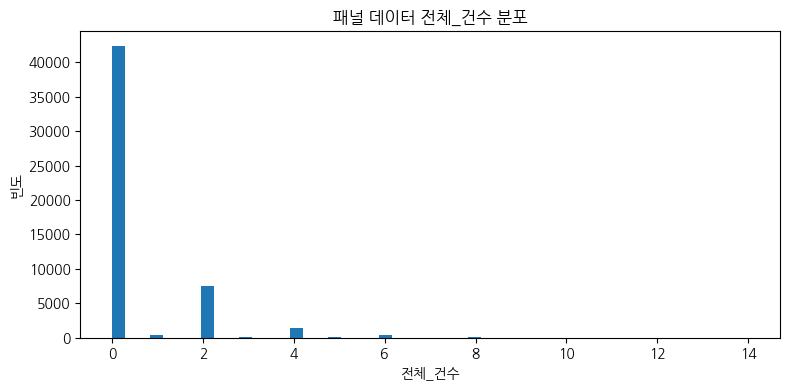

In [7]:
# 패널 데이터 품질 점검: 모델 입력 직전 상태 확인
panel_quality_df = pd.DataFrame({
    '항목': [
        '패널 전체 행 수',
        '시작_대여소 수',
        'datetime 결측 수',
        'lag_1h 결측 수',
        'lag_24h 결측 수',
        'rolling_3h 결측 수',
        '전체_건수 평균',
        '전체_건수 99% 분위수'
    ],
    '값': [
        len(df_hourly),
        df_hourly['시작_대여소_ID'].nunique(),
        int(df_hourly['datetime'].isna().sum()),
        int(df_hourly['lag_1h'].isna().sum()),
        int(df_hourly['lag_24h'].isna().sum()),
        int(df_hourly['rolling_3h'].isna().sum()),
        float(df_hourly['전체_건수'].mean()),
        float(df_hourly['전체_건수'].quantile(0.99))
    ]
})

display(panel_quality_df)

plt.figure(figsize=(8, 4))
plt.hist(df_hourly['전체_건수'], bins=50)
plt.title('패널 데이터 전체_건수 분포')
plt.xlabel('전체_건수')
plt.ylabel('빈도')
plt.tight_layout()
plt.show()

## 6. 기본 모델 학습 설정


In [8]:
target = '전체_건수'
# features = [
#     '온도',
#     '습도',
#     '불쾌지수',
#     '강수량',
#     '적설량',
# ]

In [9]:
train_base = df_hourly[df_hourly['year'] == 2024].copy()

# 스테이션 ID 대신 2024년 기준 운영 프로필 피처를 부여
train_profile = train_base.copy()
peak_hours = [8, 9, 18, 19]
train_profile['peak_target'] = train_profile['전체_건수'].where(train_profile['hour'].isin(peak_hours))

station_profile = train_profile.groupby('시작_대여소_ID', as_index=False).agg({
    'initial_bikes': 'max',
    '전체_건수': 'mean',
    'peak_target': 'mean'
}).rename(columns={
    'initial_bikes': 'initial_bikes_profile',
    '전체_건수': 'station_mean_count',
    'peak_target': 'station_peak_mean_count'
})

station_profile['station_peak_ratio'] = np.where(
    station_profile['station_mean_count'] > 0,
    station_profile['station_peak_mean_count'] / station_profile['station_mean_count'],
    0
)
station_profile = station_profile[['시작_대여소_ID', 'station_mean_count', 'station_peak_ratio']]
station_profile = station_profile.fillna(0)

df_model = df_hourly.merge(station_profile, on='시작_대여소_ID', how='left')
df_model[station_profile_features] = df_model[station_profile_features].fillna(0)

train = df_model[df_model['year'] == 2024].copy()
test = df_model[df_model['year'] == 2025].copy()

features = base_features + lag_features + station_profile_features

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

from sklearn.ensemble import HistGradientBoostingRegressor

hgb = HistGradientBoostingRegressor(
    learning_rate=0.03,
    max_iter=600,
    max_depth=10,
    min_samples_leaf=10,
    random_state=42
)

hgb.fit(X_train, np.log1p(y_train))

pred_log = hgb.predict(X_test)
pred_hgb = np.expm1(pred_log)

print("HGB MAE:", mean_absolute_error(y_test, pred_hgb))
print("HGB RMSE:", np.sqrt(mean_squared_error(y_test, pred_hgb)))
print("HGB R2:", r2_score(y_test, pred_hgb))
print("사용 피처:", features)


HGB MAE: 0.5296438405132116
HGB RMSE: 0.9679232723390766
HGB R2: 0.18002989692790416
사용 피처: ['hour', 'weekday', 'is_weekend', '온도', '습도', '강수량', '적설량', 'initial_bikes', 'lag_1h', 'lag_2h', 'lag_24h', 'rolling_3h', 'hour_sin', 'hour_cos', 'is_holiday', 'station_mean_count', 'station_peak_ratio']


## 7. 기본 모델 검증


In [10]:
# 데이터 검증: 학습/평가에 쓰인 hourly 데이터 상태 확인
validation_summary = pd.DataFrame({
    '항목': ['전체 행 수', 'datetime 결측 수', '대여소 수', '2024 행 수', '2025 행 수', '전체_건수 평균'],
    '값': [
        len(df_hourly),
        int(df_hourly['datetime'].isna().sum()),
        df_hourly['시작_대여소_ID'].nunique(),
        len(train),
        len(test),
        float(df_hourly['전체_건수'].mean()),
    ]
})

display(validation_summary)
display(df_hourly[['datetime', '시작_대여소_ID', '전체_건수']].head())

,항목,값
0,전체 행 수,52548.000000
1,datetime 결측 수,0.000000
2,대여소 수,3.000000
3,2024 행 수,26280.000000
4,2025 행 수,26268.000000
5,전체_건수 평균,0.491912


,datetime,시작_대여소_ID,전체_건수
24,2024-01-02 00:00:00,ST-464,0.0
25,2024-01-02 01:00:00,ST-464,0.0
26,2024-01-02 02:00:00,ST-464,0.0
27,2024-01-02 03:00:00,ST-464,0.0
28,2024-01-02 04:00:00,ST-464,0.0


In [11]:
# 모델 검증 1: persistence baseline(직전 1시간 값)과 비교
baseline_pred = test['lag_1h'].fillna(0).clip(lower=0)

comparison_df = pd.DataFrame({
    '모델': ['Persistence Baseline', 'HistGradientBoosting'],
    'MAE': [
        mean_absolute_error(y_test, baseline_pred),
        mean_absolute_error(y_test, pred_hgb),
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, baseline_pred)),
        np.sqrt(mean_squared_error(y_test, pred_hgb)),
    ],
    'R2': [
        r2_score(y_test, baseline_pred),
        r2_score(y_test, pred_hgb),
    ]
})

display(comparison_df)

,모델,MAE,RMSE,R2
0,Persistence Baseline,0.653038,1.372105,-0.647747
1,HistGradientBoosting,0.529644,0.967923,0.180030


In [12]:
# 모델 검증 2: 대여소별 성능과 시간대별 오차 확인
test_result = test[['시작_대여소_ID', 'datetime', 'hour', '전체_건수']].copy()
test_result['예측_건수'] = pred_hgb
test_result['절대오차'] = (test_result['전체_건수'] - test_result['예측_건수']).abs()

station_eval = test_result.groupby('시작_대여소_ID', as_index=False).agg({
    '전체_건수': 'mean',
    '예측_건수': 'mean',
    '절대오차': 'mean'
}).sort_values('절대오차', ascending=False)

hour_eval = test_result.groupby('hour', as_index=False).agg({
    '절대오차': 'mean',
    '전체_건수': 'mean',
    '예측_건수': 'mean'
})

display(station_eval)
display(hour_eval)

,시작_대여소_ID,전체_건수,예측_건수,절대오차
2,ST-481,0.670854,0.516745,0.730548
1,ST-479,0.422567,0.313167,0.523992
0,ST-464,0.245317,0.154622,0.334392


,hour,절대오차,전체_건수,예측_건수
0,0,0.374494,0.282192,0.217232
1,1,0.213527,0.131507,0.102962
2,2,0.170450,0.108676,0.074880
3,3,0.122221,0.070320,0.057915
4,4,0.088807,0.037443,0.054236
5,5,0.154006,0.111416,0.055147
6,6,0.467682,0.348858,0.405211
7,7,0.901509,0.920548,0.836924
8,8,0.898963,0.939726,0.792200
9,9,0.629880,0.557078,0.299468


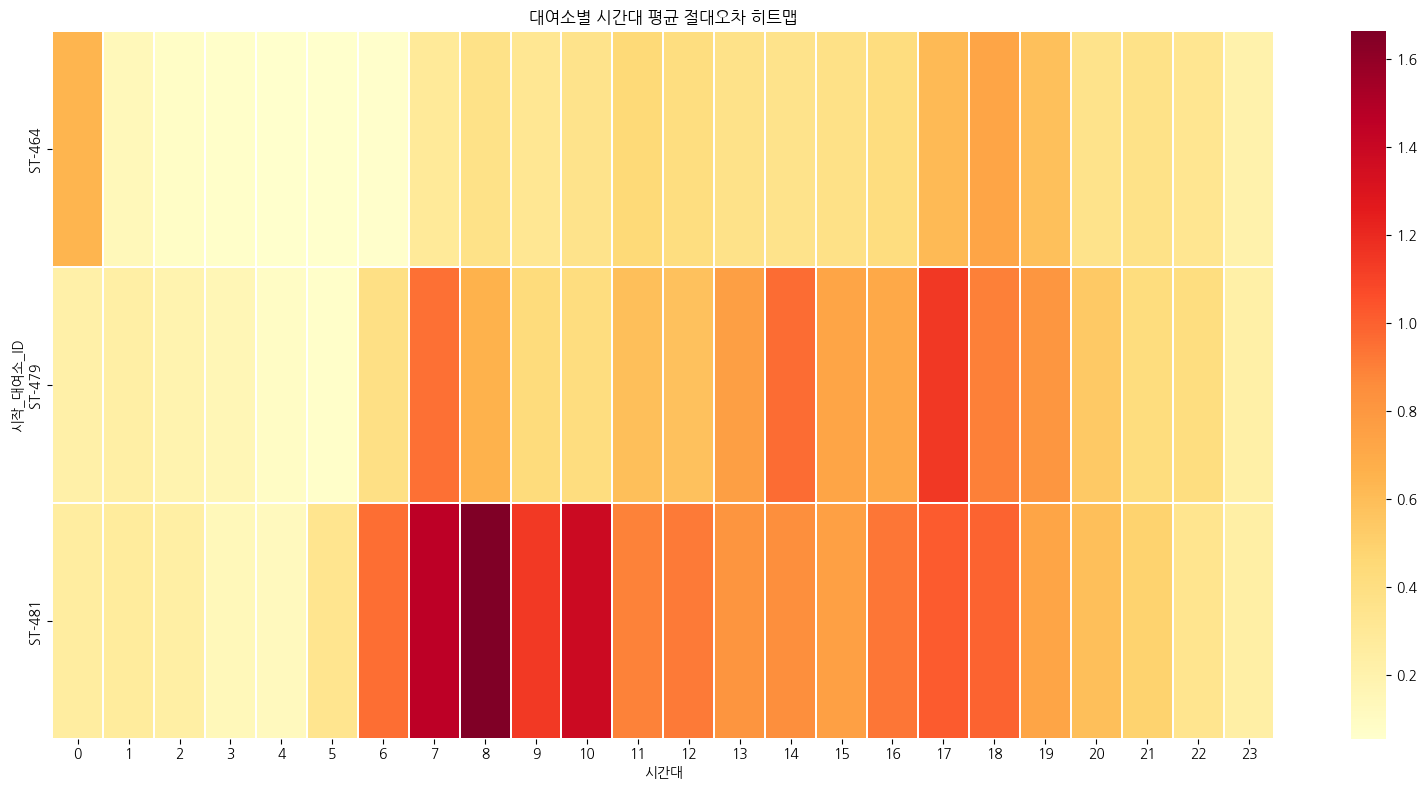

In [13]:
import seaborn as sns

# 시각화 1: 대여소-시간대 평균 절대오차 히트맵
station_hour_error = test_result.groupby(['시작_대여소_ID', 'hour'])['절대오차'].mean().reset_index()
station_hour_pivot = station_hour_error.pivot(index='시작_대여소_ID', columns='hour', values='절대오차')

plt.figure(figsize=(16, 8))
sns.heatmap(station_hour_pivot, cmap='YlOrRd', linewidths=0.2)
plt.title('대여소별 시간대 평균 절대오차 히트맵')
plt.xlabel('시간대')
plt.ylabel('시작_대여소_ID')
plt.tight_layout()
plt.show()

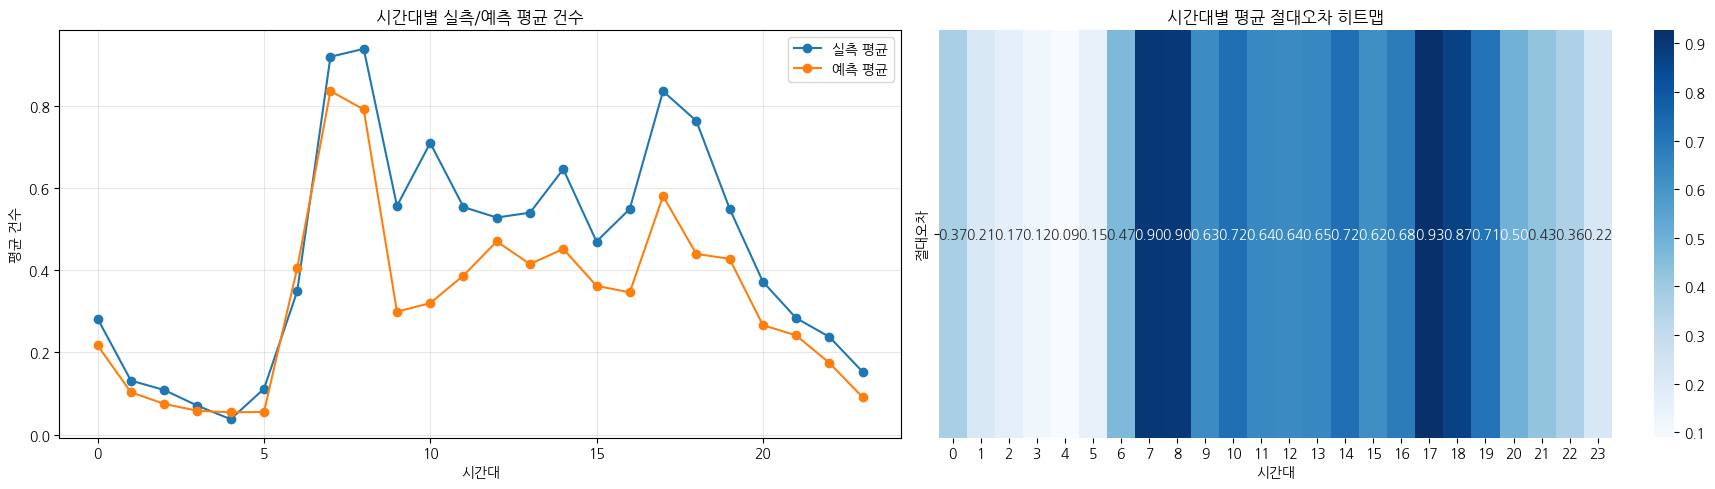

In [14]:
# 시각화 2: 시간대별 실측/예측 평균 비교 + 절대오차 히트맵
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].plot(hour_eval['hour'], hour_eval['전체_건수'], marker='o', label='실측 평균')
axes[0].plot(hour_eval['hour'], hour_eval['예측_건수'], marker='o', label='예측 평균')
axes[0].set_title('시간대별 실측/예측 평균 건수')
axes[0].set_xlabel('시간대')
axes[0].set_ylabel('평균 건수')
axes[0].legend()
axes[0].grid(alpha=0.3)

hour_error_heatmap = hour_eval.set_index('hour')[['절대오차']].T
sns.heatmap(hour_error_heatmap, cmap='Blues', annot=True, fmt='.2f', ax=axes[1])
axes[1].set_title('시간대별 평균 절대오차 히트맵')
axes[1].set_xlabel('시간대')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 8. 기본 모델 해석 및 비교


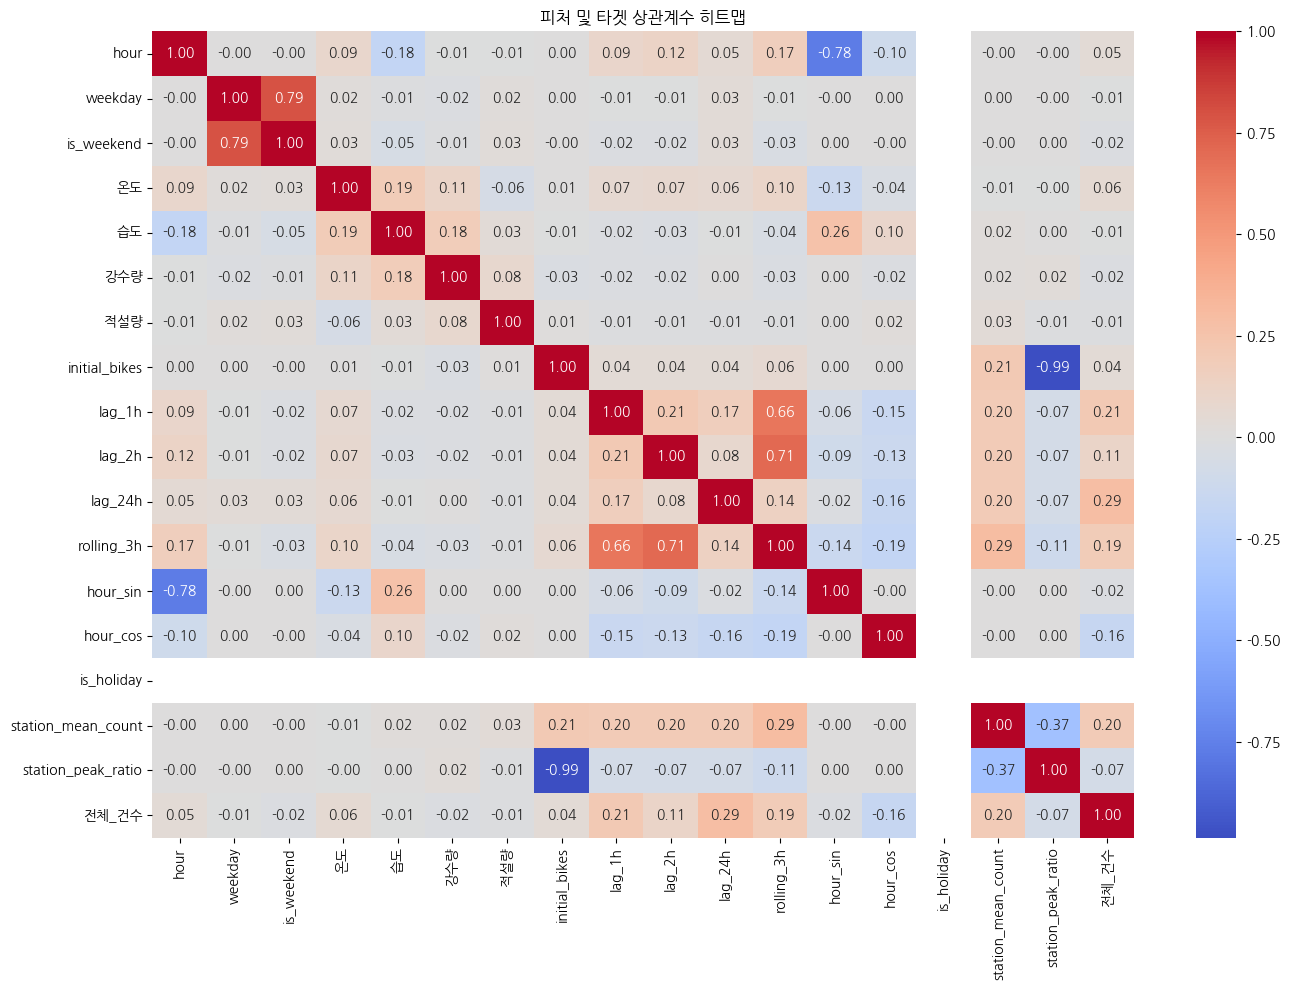

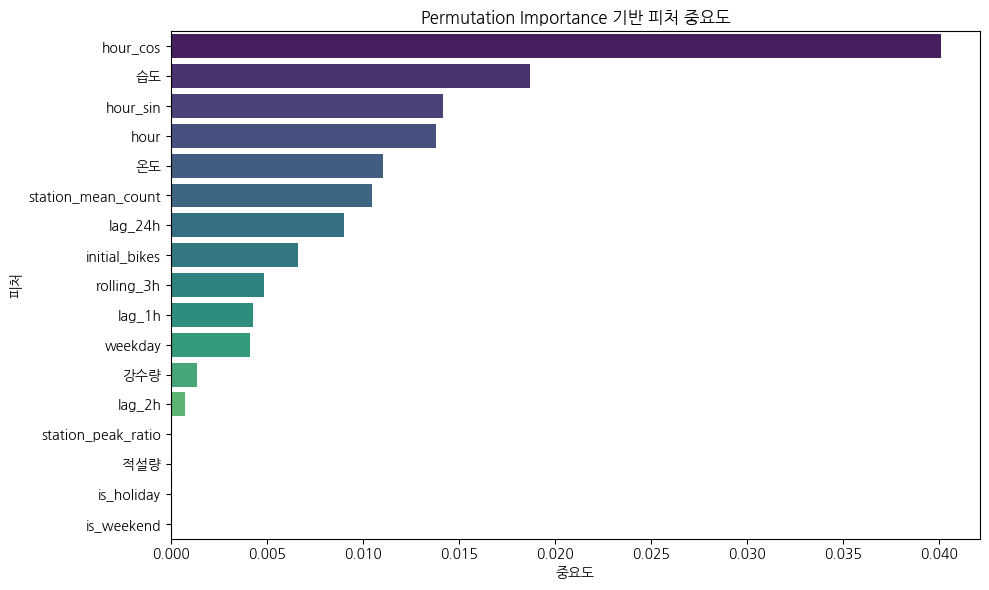

,피처,중요도
13,hour_cos,0.040122
4,습도,0.018699
12,hour_sin,0.014150
0,hour,0.013813
3,온도,0.011059
15,station_mean_count,0.010492
10,lag_24h,0.009023
7,initial_bikes,0.006609
11,rolling_3h,0.004834
8,lag_1h,0.004273


In [15]:
from sklearn.inspection import permutation_importance

# 피처 상관계수 히트맵
corr_cols = features + [target]
corr_df = train[corr_cols].copy()
corr_matrix = corr_df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.title('피처 및 타겟 상관계수 히트맵')
plt.tight_layout()
plt.show()

# permutation importance 기반 피처 중요도
perm_result = permutation_importance(
    hgb,
    X_test,
    np.log1p(y_test),
    n_repeats=5,
    random_state=42,
    scoring='neg_mean_absolute_error'
)

importance_df = pd.DataFrame({
    '피처': features,
    '중요도': perm_result.importances_mean
}).sort_values('중요도', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='중요도', y='피처', palette='viridis')
plt.title('Permutation Importance 기반 피처 중요도')
plt.xlabel('중요도')
plt.ylabel('피처')
plt.tight_layout()
plt.show()

display(importance_df)

In [16]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor

# 비교용 입력 데이터 정리
X_train_cmp = X_train.fillna(0).copy()
X_test_cmp = X_test.fillna(0).copy()
y_train_log = np.log1p(y_train)

models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'RandomForest': RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ),
    'ExtraTrees': ExtraTreesRegressor(
        n_estimators=200,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ),
    'GradientBoosting': GradientBoostingRegressor(
        learning_rate=0.05,
        n_estimators=200,
        max_depth=3,
        random_state=42
    ),
    'HistGradientBoosting': HistGradientBoostingRegressor(
        learning_rate=0.03,
        max_iter=600,
        max_depth=10,
        min_samples_leaf=10,
        random_state=42
    )
}

model_scores = []
model_predictions = {}

for model_name, model in models.items():
    model.fit(X_train_cmp, y_train_log)
    pred_log = model.predict(X_test_cmp)
    pred = np.expm1(pred_log)
    pred = np.clip(pred, 0, None)

    model_predictions[model_name] = pred
    model_scores.append({
        '모델': model_name,
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
        'R2': r2_score(y_test, pred)
    })

model_score_df = pd.DataFrame(model_scores).sort_values('RMSE')
display(model_score_df)

,모델,MAE,RMSE,R2
5,HistGradientBoosting,0.529132,0.967885,0.180095
2,RandomForest,0.542127,0.976046,0.166211
3,ExtraTrees,0.535767,0.977232,0.164182
4,GradientBoosting,0.545948,0.984794,0.151196
0,LinearRegression,0.574771,1.027348,0.076256
1,Ridge,0.574775,1.027353,0.076248


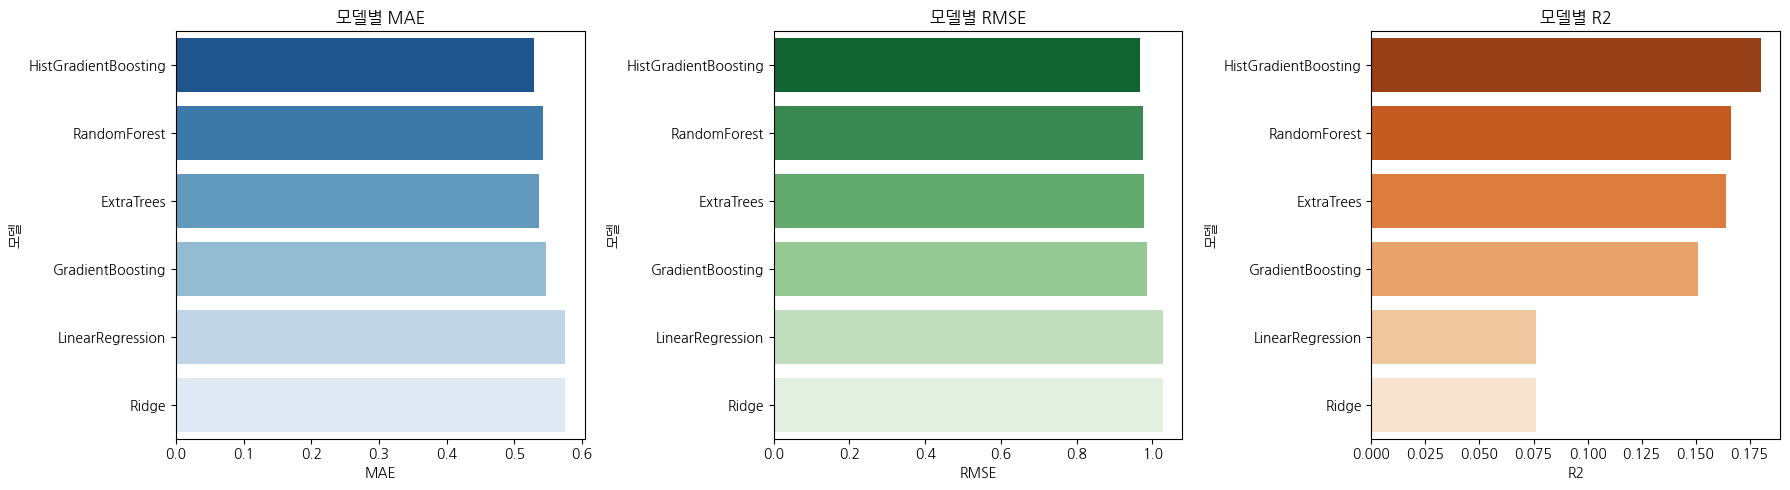

In [17]:
# 모델별 성능 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=model_score_df, x='MAE', y='모델', ax=axes[0], palette='Blues_r')
axes[0].set_title('모델별 MAE')

sns.barplot(data=model_score_df, x='RMSE', y='모델', ax=axes[1], palette='Greens_r')
axes[1].set_title('모델별 RMSE')

sns.barplot(data=model_score_df, x='R2', y='모델', ax=axes[2], palette='Oranges_r')
axes[2].set_title('모델별 R2')

plt.tight_layout()
plt.show()

## 9. 추천 모델: 시간/날씨/구조/lag 기반 HGB


In [18]:
# 추천 분석 방향: 공통 모델에 station profile을 더해 스테이션별 차이를 보정
shared_base_features = base_features + lag_features
recommended_features = shared_base_features + station_profile_features

model_df = df_model.copy()
model_df['month'] = model_df['datetime'].dt.month

# 2024년 내부 시계열 검증: 1~9월 학습, 10~12월 검증
train_2024 = model_df[model_df['year'] == 2024].copy()
valid_2024 = train_2024[train_2024['month'] >= 10].copy()
subtrain_2024 = train_2024[train_2024['month'] < 10].copy()
test_2025_reco = model_df[model_df['year'] == 2025].copy()

common_hgb = HistGradientBoostingRegressor(
    learning_rate=0.03,
    max_iter=500,
    max_depth=8,
    min_samples_leaf=20,
    l2_regularization=0.1,
    random_state=42
)

profile_hgb = HistGradientBoostingRegressor(
    learning_rate=0.03,
    max_iter=500,
    max_depth=8,
    min_samples_leaf=20,
    l2_regularization=0.1,
    random_state=42
)

common_hgb.fit(subtrain_2024[shared_base_features].fillna(0), np.log1p(subtrain_2024[target]))
profile_hgb.fit(subtrain_2024[recommended_features].fillna(0), np.log1p(subtrain_2024[target]))

common_valid_pred = np.clip(np.expm1(common_hgb.predict(valid_2024[shared_base_features].fillna(0))), 0, None)
profile_valid_pred = np.clip(np.expm1(profile_hgb.predict(valid_2024[recommended_features].fillna(0))), 0, None)

comparison_result_df = pd.DataFrame([
    {
        '모델 버전': '공통 모델(시간/날씨/lag)',
        '구간': '2024 holdout (10~12월)',
        'MAE': mean_absolute_error(valid_2024[target], common_valid_pred),
        'RMSE': np.sqrt(mean_squared_error(valid_2024[target], common_valid_pred)),
        'R2': r2_score(valid_2024[target], common_valid_pred)
    },
    {
        '모델 버전': '공통 모델 + station profile',
        '구간': '2024 holdout (10~12월)',
        'MAE': mean_absolute_error(valid_2024[target], profile_valid_pred),
        'RMSE': np.sqrt(mean_squared_error(valid_2024[target], profile_valid_pred)),
        'R2': r2_score(valid_2024[target], profile_valid_pred)
    }
])

common_hgb.fit(train_2024[shared_base_features].fillna(0), np.log1p(train_2024[target]))
profile_hgb.fit(train_2024[recommended_features].fillna(0), np.log1p(train_2024[target]))

common_pred_2025 = np.clip(
    np.expm1(common_hgb.predict(test_2025_reco[shared_base_features].fillna(0))),
    0,
    None
)
recommended_pred_2025 = np.clip(
    np.expm1(profile_hgb.predict(test_2025_reco[recommended_features].fillna(0))),
    0,
    None
)

test_result_df = pd.DataFrame([
    {
        '모델 버전': '공통 모델(시간/날씨/lag)',
        '구간': '2025 test',
        'MAE': mean_absolute_error(test_2025_reco[target], common_pred_2025),
        'RMSE': np.sqrt(mean_squared_error(test_2025_reco[target], common_pred_2025)),
        'R2': r2_score(test_2025_reco[target], common_pred_2025)
    },
    {
        '모델 버전': '공통 모델 + station profile',
        '구간': '2025 test',
        'MAE': mean_absolute_error(test_2025_reco[target], recommended_pred_2025),
        'RMSE': np.sqrt(mean_squared_error(test_2025_reco[target], recommended_pred_2025)),
        'R2': r2_score(test_2025_reco[target], recommended_pred_2025)
    }
])

recommended_hgb = profile_hgb
X_test_reco = test_2025_reco[recommended_features].fillna(0)
y_test_reco = test_2025_reco[target]

display(pd.concat([comparison_result_df, test_result_df], ignore_index=True))
print('공통 피처 수:', len(shared_base_features))
print(shared_base_features)
print('추천 피처 수:', len(recommended_features))
print(recommended_features)


,모델 버전,구간,MAE,RMSE,R2
0,공통 모델(시간/날씨/lag),2024 holdout (10~12월),0.634419,1.149886,0.237576
1,공통 모델 + station profile,2024 holdout (10~12월),0.633298,1.153873,0.232279
2,공통 모델(시간/날씨/lag),2025 test,0.528405,0.967235,0.181195
3,공통 모델 + station profile,2025 test,0.527963,0.964680,0.185515


공통 피처 수: 15
['hour', 'weekday', 'is_weekend', '온도', '습도', '강수량', '적설량', 'initial_bikes', 'lag_1h', 'lag_2h', 'lag_24h', 'rolling_3h', 'hour_sin', 'hour_cos', 'is_holiday']
추천 피처 수: 17
['hour', 'weekday', 'is_weekend', '온도', '습도', '강수량', '적설량', 'initial_bikes', 'lag_1h', 'lag_2h', 'lag_24h', 'rolling_3h', 'hour_sin', 'hour_cos', 'is_holiday', 'station_mean_count', 'station_peak_ratio']


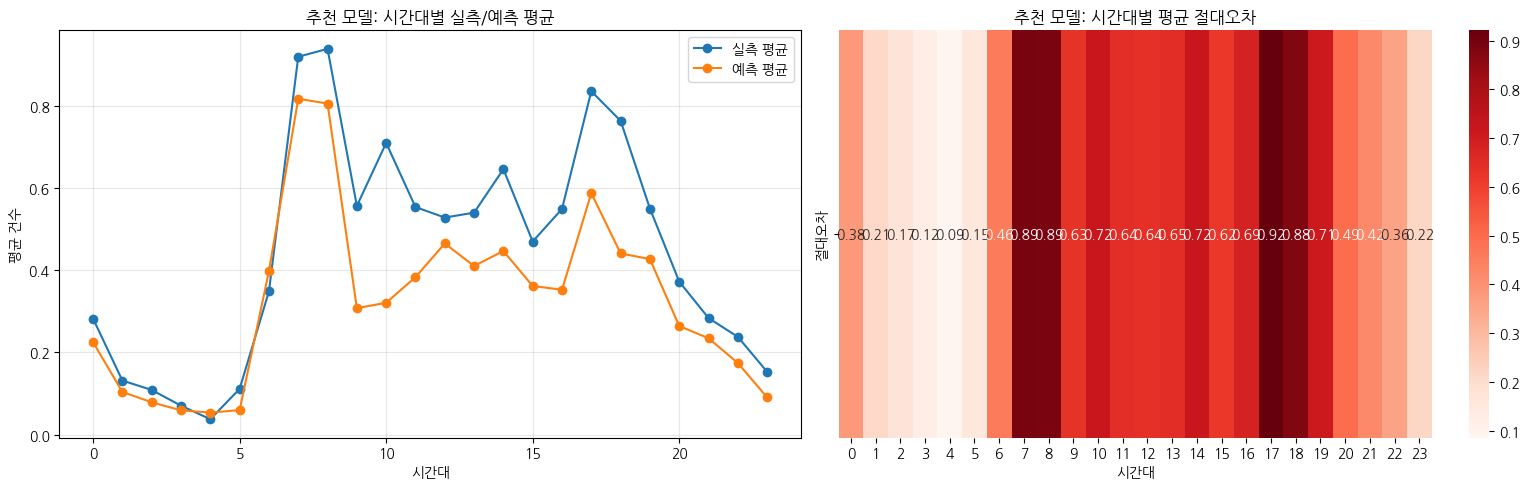

In [19]:
# 추천 모델 결과 시각화
recommended_eval_df = test_2025_reco[['datetime', '시작_대여소_ID', 'hour', '전체_건수']].copy()
recommended_eval_df['예측_건수'] = recommended_pred_2025
recommended_eval_df['절대오차'] = (
    recommended_eval_df['전체_건수'] - recommended_eval_df['예측_건수']
).abs()

recommended_hour_eval = recommended_eval_df.groupby('hour', as_index=False).agg({
    '전체_건수': 'mean',
    '예측_건수': 'mean',
    '절대오차': 'mean'
})

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(recommended_hour_eval['hour'], recommended_hour_eval['전체_건수'], marker='o', label='실측 평균')
axes[0].plot(recommended_hour_eval['hour'], recommended_hour_eval['예측_건수'], marker='o', label='예측 평균')
axes[0].set_title('추천 모델: 시간대별 실측/예측 평균')
axes[0].set_xlabel('시간대')
axes[0].set_ylabel('평균 건수')
axes[0].legend()
axes[0].grid(alpha=0.3)

sns.heatmap(
    recommended_hour_eval.set_index('hour')[['절대오차']].T,
    cmap='Reds',
    annot=True,
    fmt='.2f',
    ax=axes[1]
)
axes[1].set_title('추천 모델: 시간대별 평균 절대오차')
axes[1].set_xlabel('시간대')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

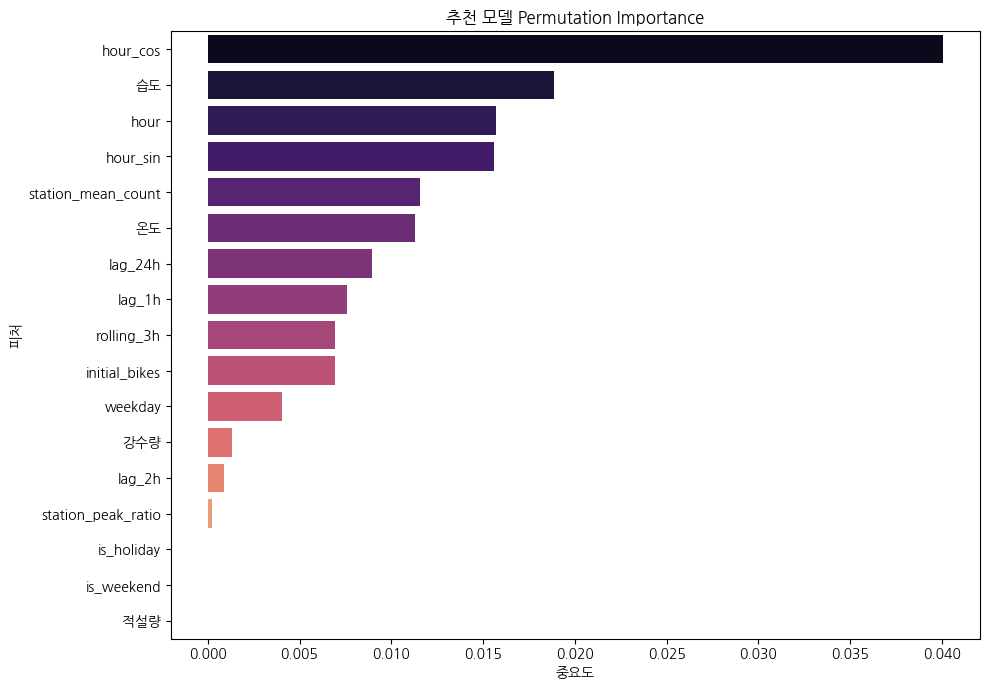

,피처,중요도
13,hour_cos,0.040064
4,습도,0.018853
0,hour,0.015694
12,hour_sin,0.015577
15,station_mean_count,0.011559
3,온도,0.011298
10,lag_24h,0.008957
8,lag_1h,0.007560
11,rolling_3h,0.006933
7,initial_bikes,0.006908


In [20]:
# 추천 모델 피처 중요도
recommended_perm = permutation_importance(
    recommended_hgb,
    X_test_reco,
    np.log1p(y_test_reco),
    n_repeats=5,
    random_state=42,
    scoring='neg_mean_absolute_error'
)

recommended_importance_df = pd.DataFrame({
    '피처': recommended_features,
    '중요도': recommended_perm.importances_mean
}).sort_values('중요도', ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(data=recommended_importance_df, x='중요도', y='피처', palette='magma')
plt.title('추천 모델 Permutation Importance')
plt.xlabel('중요도')
plt.ylabel('피처')
plt.tight_layout()
plt.show()

display(recommended_importance_df)

## 추천 모델 컬럼 설명

- `hour`: 이용이 발생한 시간대의 시(0~23)
- `weekday`: 요일 숫자. 월요일=0, 일요일=6
- `is_weekend`: 주말 여부. 평일=0, 주말=1
- `온도`: 해당 시간대 기온
- `습도`: 해당 시간대 상대습도
- `강수량`: 해당 시간대 강수량
- `적설량`: 해당 시간대 적설량
- `initial_bikes`: 해당 스테이션의 초기 보유 대수(`LCD + QR`)
- `lag_1h`: 1시간 전 같은 대여소의 전체 대여 건수
- `lag_2h`: 2시간 전 같은 대여소의 전체 대여 건수
- `lag_24h`: 24시간 전 같은 대여소의 전체 대여 건수
- `rolling_3h`: 직전 3시간 대여 건수 평균
- `hour_sin`: 시간대의 주기성을 사인값으로 변환한 피처
- `hour_cos`: 시간대의 주기성을 코사인값으로 변환한 피처
- `is_holiday`: 공휴일 여부. 공휴일=1, 그 외=0
- `station_mean_count`: 2024년 기준 스테이션 평균 대여량
- `station_peak_ratio`: 출퇴근 피크 시간 평균 대여량 / 전체 평균 대여량

해석 포인트:

- `lag_1h`, `lag_24h`, `rolling_3h`가 높으면 최근 수요 흐름이 중요하다는 뜻입니다.
- `initial_bikes`, `station_mean_count`, `station_peak_ratio`가 높으면 스테이션 운영 특성이 중요하다는 뜻입니다.
- `hour`, `hour_sin`, `hour_cos`가 높으면 시간대 패턴이 중요하다는 뜻입니다.
- 날씨 관련 컬럼 중요도가 높으면 기상 조건이 수요 변화에 영향을 준다는 뜻입니다.


## 10. 필요 대수 산출


In [21]:
# 예측 수요를 운영용 필요 대수로 변환
train_pred_for_buffer = np.clip(
    np.expm1(recommended_hgb.predict(train_2024[recommended_features].fillna(0))),
    0,
    None
)
residual_buffer = float(np.quantile(np.maximum(train_2024[target] - train_pred_for_buffer, 0), 0.9))

need_forecast_df = test_2025_reco[[
    '시작_대여소_ID', 'datetime', 'initial_bikes', target
]].copy()
need_forecast_df['predicted_demand'] = recommended_pred_2025
need_forecast_df['safety_buffer'] = residual_buffer
need_forecast_df['predicted_needed_bikes'] = np.clip(
    np.ceil(need_forecast_df['predicted_demand'] + residual_buffer - need_forecast_df['initial_bikes']),
    0,
    None
)

station_need_summary_df = need_forecast_df.groupby('시작_대여소_ID', as_index=False).agg({
    'initial_bikes': 'max',
    'predicted_demand': ['mean', 'max'],
    'predicted_needed_bikes': ['mean', 'max']
})
station_need_summary_df.columns = [
    '시작_대여소_ID',
    'initial_bikes',
    'predicted_demand_mean',
    'predicted_demand_max',
    'predicted_needed_bikes_mean',
    'predicted_needed_bikes_max'
]

display(station_need_summary_df)
print('안전 버퍼(학습 잔차 90분위):', round(residual_buffer, 3))


,시작_대여소_ID,initial_bikes,predicted_demand_mean,predicted_demand_max,predicted_needed_bikes_mean,predicted_needed_bikes_max
0,ST-464,13.0,0.154998,1.491844,0.0,0.0
1,ST-479,19.0,0.313889,2.404142,0.0,0.0
2,ST-481,15.0,0.515665,5.174986,0.0,0.0


안전 버퍼(학습 잔차 90분위): 1.572


## 최종 권장 파이프라인 정리

현재 노트북 기준 최종 권장 파이프라인은 아래와 같습니다.

1. `2024_data`, `2025_data`를 합친 뒤 선택한 스테이션만 필터링합니다.
2. `기준_날짜 + 시간대`를 기준으로 스테이션별 시간 패널 데이터를 만듭니다.
3. 비어 있는 시간대는 `전체_건수=0`으로 채우고, 날씨는 `ffill/bfill`로 보완합니다.
4. `LCD + QR`를 합쳐 `initial_bikes`를 만들고, 위치/ID 계열 컬럼은 모델 입력에서 제외합니다.
5. 시간 피처(`hour`, `weekday`, `is_weekend`, `is_holiday`, `hour_sin`, `hour_cos`)를 생성합니다.
6. 최근 수요 피처(`lag_1h`, `lag_2h`, `lag_24h`, `rolling_3h`)를 생성합니다.
7. 2024년 기준 스테이션 운영 프로필(`station_mean_count`, `station_peak_ratio`)을 생성합니다.
8. 공통 모델은 `시간/날씨/lag + station profile`로 학습합니다.
9. 필요 대수는 `예측 수요 + safety buffer - initial_bikes`로 계산합니다.
10. 별도로 스테이션별 개별 모델도 학습해 공통 모델과 비교합니다.

해석상 핵심은 다음입니다.

- 이 모델은 `최근 수요 흐름 + 시간대 패턴 + 초기 보유 대수 + 스테이션 운영 프로필`을 바탕으로 예측합니다.
- 따라서 운영상 "어느 스테이션에 몇 대가 더 필요할지"를 바로 계산하기 쉬운 구조입니다.
- `station_id`, `위도`, `경도` 없이도 스테이션 차이를 반영하도록 설계를 바꿨다는 점이 핵심입니다.


## 11. 월별 유사도 점검 및 삭제 원칙

월별 데이터가 비슷하다고 해서 자동으로 삭제하지는 않습니다.

- `완전 중복`은 제거 대상입니다.
- `유사한 월`은 계절성 또는 정상적인 반복 패턴일 수 있으므로 기본적으로 유지합니다.
- 대신 월별 유사도를 계산해서, 너무 비슷한 월 조합이 있는지 확인하고 필요 시 별도 판단합니다.


,항목,값
0,패널 중복 행 수,0


,month,전체_건수,lag_1h,lag_24h,rolling_3h,온도,습도,불쾌지수,강수량,적설량
0,1,726.0,0.335185,0.332407,0.335185,-1.358657,58.649537,36.135179,4.4,2.38
1,2,745.0,0.356801,0.350096,0.356162,3.036111,70.823755,40.631675,60.2,21.07
2,3,1058.0,0.474910,0.474014,0.474910,5.922267,59.937724,45.870298,67.3,19.32
3,4,1473.0,0.681944,0.679167,0.681636,14.841481,59.517130,57.981100,40.0,0.00
4,5,1171.0,0.524642,0.525090,0.523746,17.887500,61.030018,62.378608,29.6,0.00
5,6,1526.0,0.705556,0.718056,0.706636,23.483333,62.078241,70.162577,212.4,0.00
6,7,849.0,0.381272,0.380824,0.381422,25.510484,85.542563,76.057014,538.8,0.00
7,8,1207.0,0.539427,0.534050,0.539128,27.290547,82.741039,78.715024,459.8,0.00
8,9,1368.0,0.633796,0.625926,0.633488,23.637315,79.493981,72.617512,577.2,0.00
9,10,1751.0,0.785394,0.784498,0.785693,15.096057,74.562276,58.814369,32.7,0.00


month,1,2,3,4,5,6,7,8,9,10,11,12
month,,,,,,,,,,,,
1,1.000000,0.996821,0.997911,0.998842,0.999253,0.990354,0.848551,0.936705,0.923706,0.999010,0.999206,0.999870
2,0.996821,1.000000,0.999026,0.996603,0.997130,0.996395,0.885351,0.959518,0.948805,0.996138,0.997018,0.996351
3,0.997911,0.999026,1.000000,0.999029,0.999001,0.996873,0.876527,0.955042,0.944231,0.998686,0.999105,0.998092
4,0.998842,0.996603,0.999029,1.000000,0.999821,0.993819,0.857995,0.943564,0.931711,0.999944,0.999933,0.999358
5,0.999253,0.997130,0.999001,0.999821,1.000000,0.993552,0.858131,0.943467,0.931253,0.999719,0.999801,0.999508
6,0.990354,0.996395,0.996873,0.993819,0.993552,1.000000,0.909429,0.974384,0.966207,0.992783,0.993636,0.990765
7,0.848551,0.885351,0.876527,0.857995,0.858131,0.909429,1.000000,0.979651,0.985464,0.853484,0.857887,0.847743
8,0.936705,0.959518,0.955042,0.943564,0.943467,0.974384,0.979651,1.000000,0.999242,0.940629,0.943410,0.936499
9,0.923706,0.948805,0.944231,0.931711,0.931253,0.966207,0.985464,0.999242,1.000000,0.928545,0.931498,0.923695


,월1,월2,유사도
23,4,10,0.999944
24,4,11,0.999933
35,10,11,0.999933
7,1,12,0.999870
21,4,5,0.999821
28,5,11,0.999801
27,5,10,0.999719
37,11,12,0.999606
36,10,12,0.999542
29,5,12,0.999508


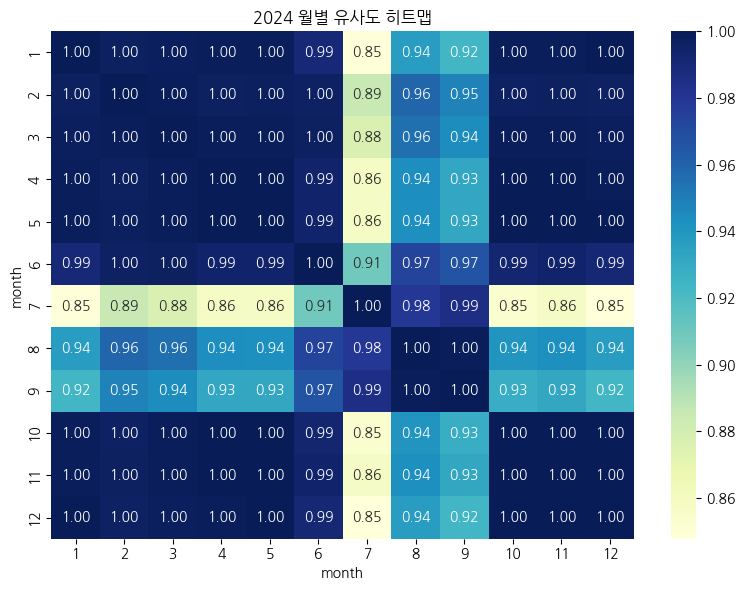

In [22]:
# 월별 유사도 점검: 비슷한 월은 리포트만 하고 기본적으로 삭제하지 않음
from sklearn.metrics.pairwise import cosine_similarity
panel_duplicate_count = df_hourly.duplicated(subset=['시작_대여소_ID', 'datetime']).sum()

monthly_check_df = train_2024.copy()
monthly_check_df['month'] = monthly_check_df['datetime'].dt.month
monthly_summary = monthly_check_df.groupby('month', as_index=False).agg({
    '전체_건수': 'sum',
    'lag_1h': 'mean',
    'lag_24h': 'mean',
    'rolling_3h': 'mean',
    '온도': 'mean',
    '습도': 'mean',
    '불쾌지수': 'mean',
    '강수량': 'sum',
    '적설량': 'sum'
})

monthly_feature_cols = ['전체_건수', 'lag_1h', 'lag_24h', 'rolling_3h', '온도', '습도', '불쾌지수', '강수량', '적설량']
monthly_similarity = pd.DataFrame(
    cosine_similarity(monthly_summary[monthly_feature_cols]),
    index=monthly_summary['month'],
    columns=monthly_summary['month']
)

high_similarity_pairs = []
for i, month_i in enumerate(monthly_similarity.index):
    for j, month_j in enumerate(monthly_similarity.columns):
        if j <= i:
            continue
        sim = monthly_similarity.loc[month_i, month_j]
        if sim >= 0.98:
            high_similarity_pairs.append({'월1': int(month_i), '월2': int(month_j), '유사도': float(sim)})

high_similarity_df = pd.DataFrame(high_similarity_pairs).sort_values('유사도', ascending=False) if high_similarity_pairs else pd.DataFrame(columns=['월1', '월2', '유사도'])

display(pd.DataFrame({'항목': ['패널 중복 행 수'], '값': [int(panel_duplicate_count)]}))
display(monthly_summary)
display(monthly_similarity)
display(high_similarity_df)

plt.figure(figsize=(8, 6))
sns.heatmap(monthly_similarity, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('2024 월별 유사도 히트맵')
plt.tight_layout()
plt.show()


## 12. 2024 Train/Valid, 2025 Test 기반 모델 튜닝 및 비교

이 섹션에서는 아래 원칙으로 모델을 선택합니다.

- `2024년` 내부에서 여러 시점의 rolling/expanding validation을 사용합니다.
- 특정 몇 개 월만 valid로 두는 단일 split은 계절성 편향이 커질 수 있으므로, 여러 fold 평균 성능으로 선택합니다.
- `2025년 전체`는 최종 일반화 테스트(test)로만 사용합니다.

추천 피처(`base_features + lag_features`)만 사용하고, 여러 모델을 비교한 뒤 rolling validation 평균 성능 기준 최적 파라미터를 선택합니다.


In [23]:
from sklearn.model_selection import ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from ast import literal_eval

# 최종 비교용 데이터셋 정의
final_features = recommended_features
final_test = model_df[model_df['year'] == 2025].copy()
X_final_test = final_test[final_features].fillna(0)
y_final_test = final_test[target]

# 2024 내부 rolling/expanding validation fold 정의
validation_folds = [
    {'fold': 'Fold1', 'train_month_end': 3, 'valid_months': [4, 5]},
    {'fold': 'Fold2', 'train_month_end': 5, 'valid_months': [6, 7]},
    {'fold': 'Fold3', 'train_month_end': 7, 'valid_months': [8, 9]},
    {'fold': 'Fold4', 'train_month_end': 9, 'valid_months': [10, 11, 12]}
]

search_space = {
    'Ridge': {
        'model_class': Pipeline,
        'pipeline_steps': [('scaler', StandardScaler()), ('model', Ridge())],
        'param_grid': {
            'model__alpha': [0.1, 1.0, 10.0, 30.0]
        }
    },
    'RandomForest': {
        'model_class': RandomForestRegressor,
        'fixed_params': {'random_state': 42, 'n_jobs': -1},
        'param_grid': {
            'n_estimators': [200],
            'max_depth': [8, 12, None],
            'min_samples_leaf': [1, 5, 10]
        }
    },
    'ExtraTrees': {
        'model_class': ExtraTreesRegressor,
        'fixed_params': {'random_state': 42, 'n_jobs': -1},
        'param_grid': {
            'n_estimators': [200],
            'max_depth': [8, 12, None],
            'min_samples_leaf': [1, 5, 10]
        }
    },
    'GradientBoosting': {
        'model_class': GradientBoostingRegressor,
        'fixed_params': {'random_state': 42},
        'param_grid': {
            'learning_rate': [0.03, 0.05],
            'n_estimators': [150, 250],
            'max_depth': [2, 3]
        }
    },
    'HistGradientBoosting': {
        'model_class': HistGradientBoostingRegressor,
        'fixed_params': {'random_state': 42},
        'param_grid': {
            'learning_rate': [0.03, 0.05],
            'max_iter': [300, 500],
            'max_depth': [6, 8, 10],
            'min_samples_leaf': [10, 20],
            'l2_regularization': [0.0, 0.1]
        }
    }
}

validation_search_results = []

for model_name, cfg in search_space.items():
    for params in ParameterGrid(cfg['param_grid']):
        fold_scores = []

        for fold_cfg in validation_folds:
            fold_train = model_df[(model_df['year'] == 2024) & (model_df['month'] <= fold_cfg['train_month_end'])].copy()
            fold_valid = model_df[(model_df['year'] == 2024) & (model_df['month'].isin(fold_cfg['valid_months']))].copy()

            X_fold_train = fold_train[final_features].fillna(0)
            y_fold_train = fold_train[target]
            X_fold_valid = fold_valid[final_features].fillna(0)
            y_fold_valid = fold_valid[target]

            if len(fold_train) == 0 or len(fold_valid) == 0:
                continue

            if cfg['model_class'] is Pipeline:
                model = cfg['model_class'](cfg['pipeline_steps'])
                model.set_params(**params)
            else:
                all_params = {}
                all_params.update(cfg.get('fixed_params', {}))
                all_params.update(params)
                model = cfg['model_class'](**all_params)

            model.fit(X_fold_train, np.log1p(y_fold_train))
            valid_pred = np.clip(np.expm1(model.predict(X_fold_valid)), 0, None)
            fold_scores.append({
                'fold': fold_cfg['fold'],
                'mae': mean_absolute_error(y_fold_valid, valid_pred),
                'rmse': np.sqrt(mean_squared_error(y_fold_valid, valid_pred)),
                'r2': r2_score(y_fold_valid, valid_pred)
            })

        if len(fold_scores) == 0:
            continue

        validation_search_results.append({
            '모델': model_name,
            '파라미터': str(params),
            'Avg_Valid_MAE': float(np.mean([x['mae'] for x in fold_scores])),
            'Avg_Valid_RMSE': float(np.mean([x['rmse'] for x in fold_scores])),
            'Avg_Valid_R2': float(np.mean([x['r2'] for x in fold_scores])),
            '사용_Fold수': len(fold_scores)
        })

validation_result_table = pd.DataFrame(validation_search_results).sort_values(['Avg_Valid_RMSE', 'Avg_Valid_MAE'])
best_validation_table = validation_result_table.groupby('모델', as_index=False).first().sort_values('Avg_Valid_RMSE')

display(best_validation_table)
print('검증 기준 최고 모델:', best_validation_table.iloc[0]['모델'])
print('검증 기준 최고 파라미터:', best_validation_table.iloc[0]['파라미터'])


,모델,파라미터,Avg_Valid_MAE,Avg_Valid_RMSE,Avg_Valid_R2,사용_Fold수
0,ExtraTrees,"{'max_depth': None, 'min_samples_leaf': 5, 'n_...",0.639757,1.165088,0.209803,4
2,HistGradientBoosting,"{'l2_regularization': 0.0, 'learning_rate': 0....",0.652190,1.177286,0.193134,4
3,RandomForest,"{'max_depth': None, 'min_samples_leaf': 5, 'n_...",0.671227,1.178114,0.191822,4
1,GradientBoosting,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",0.695967,1.202872,0.157435,4
4,Ridge,{'model__alpha': 0.1},0.691308,1.260927,0.073876,4


검증 기준 최고 모델: ExtraTrees
검증 기준 최고 파라미터: {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 200}


In [24]:
# rolling validation에서 고른 최적 모델을 2024 전체로 재학습 후 2025 테스트 평가
best_model_name = best_validation_table.iloc[0]['모델']
best_param_text = best_validation_table.iloc[0]['파라미터']

best_cfg = search_space[best_model_name]
best_params = literal_eval(best_param_text)

if best_cfg['model_class'] is Pipeline:
    final_best_model = best_cfg['model_class'](best_cfg['pipeline_steps'])
    final_best_model.set_params(**best_params)
else:
    final_param_dict = {}
    final_param_dict.update(best_cfg.get('fixed_params', {}))
    final_param_dict.update(best_params)
    final_best_model = best_cfg['model_class'](**final_param_dict)

X_2024_full = model_df[model_df['year'] == 2024][final_features].fillna(0)
y_2024_full = model_df[model_df['year'] == 2024][target]

final_best_model.fit(X_2024_full, np.log1p(y_2024_full))
final_test_pred = np.clip(np.expm1(final_best_model.predict(X_final_test)), 0, None)

final_test_result_df = pd.DataFrame({
    '최종 선택 모델': [best_model_name],
    '최종 파라미터': [best_param_text],
    'Test_MAE': [mean_absolute_error(y_final_test, final_test_pred)],
    'Test_RMSE': [np.sqrt(mean_squared_error(y_final_test, final_test_pred))],
    'Test_R2': [r2_score(y_final_test, final_test_pred)]
})

display(final_test_result_df)


,최종 선택 모델,최종 파라미터,Test_MAE,Test_RMSE,Test_R2
0,ExtraTrees,"{'max_depth': None, 'min_samples_leaf': 5, 'n_...",0.531805,0.974801,0.168336


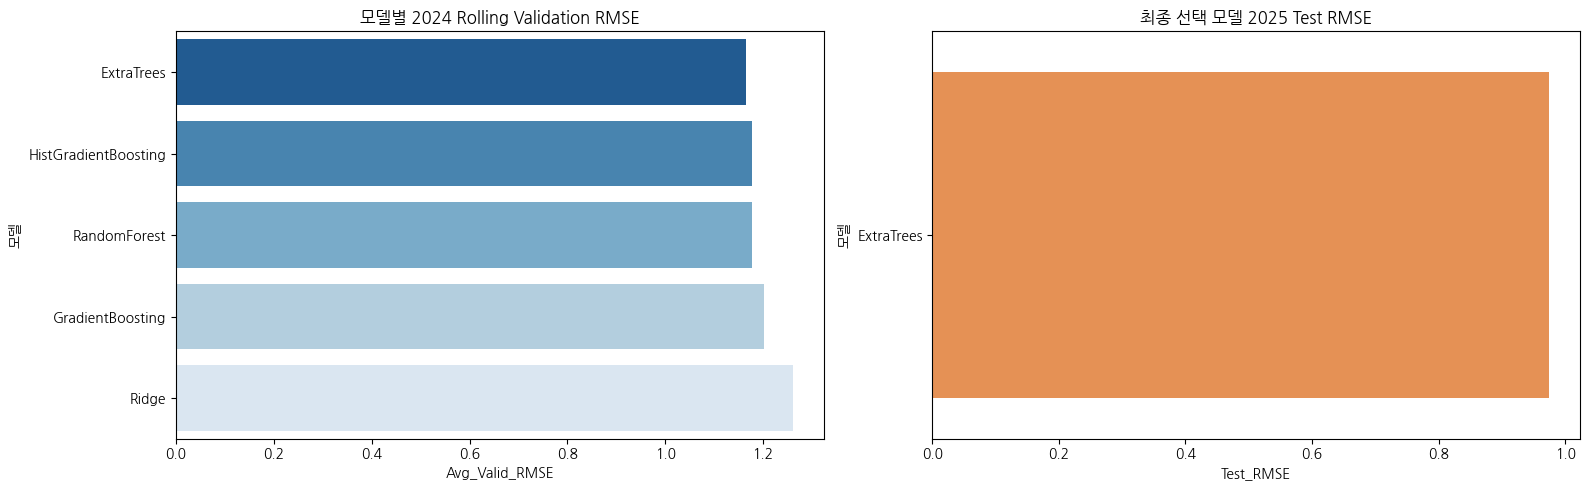

In [25]:
# 모델별 rolling valid / test 성능 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=best_validation_table, x='Avg_Valid_RMSE', y='모델', ax=axes[0], palette='Blues_r')
axes[0].set_title('모델별 2024 Rolling Validation RMSE')

plot_test_df = final_test_result_df.copy()
plot_test_df['모델'] = plot_test_df['최종 선택 모델']
sns.barplot(data=plot_test_df, x='Test_RMSE', y='모델', ax=axes[1], palette='Oranges_r')
axes[1].set_title('최종 선택 모델 2025 Test RMSE')

plt.tight_layout()
plt.show()


## 13. 실무 해석 메모

- 월별 유사도가 높더라도 기본적으로는 삭제하지 않습니다. 이는 계절성과 반복 패턴일 가능성이 높기 때문입니다.
- 삭제 대상은 `완전 중복` 또는 명백한 데이터 오류입니다.
- 최종 모델 선택은 `2024 rolling validation 평균 성능`으로 하고, 일반화 평가는 `2025 test`로 확인합니다.
- 여러 모델을 비교하되, 최종 운영 모델은 해석성과 안정성을 함께 고려해 선택합니다.


## 14. 스테이션별 개별 모델 분석

합산 모델 외에, 각 스테이션을 따로 떼어서 개별 모델을 학습/평가합니다.

- 대상: `ST-464`, `ST-481`, `ST-479`
- 검증: 2024 rolling validation
- 테스트: 2025 전체
- 개별 모델에서는 스테이션 위치/군집 피처가 상수이므로 제외하고, 시간/날씨/lag 중심으로 학습합니다.


In [26]:
# 스테이션별 개별 모델용 피처 정의
individual_stations = ['ST-464', 'ST-481', 'ST-479']
individual_features = [c for c in shared_base_features if c != 'initial_bikes']

station_search_space = {
    'Ridge': {
        'model_class': Pipeline,
        'pipeline_steps': [('scaler', StandardScaler()), ('model', Ridge())],
        'param_grid': {'model__alpha': [0.1, 1.0, 10.0, 30.0]}
    },
    'RandomForest': {
        'model_class': RandomForestRegressor,
        'fixed_params': {'random_state': 42, 'n_jobs': -1},
        'param_grid': {'n_estimators': [200], 'max_depth': [8, 12, None], 'min_samples_leaf': [1, 5, 10]}
    },
    'ExtraTrees': {
        'model_class': ExtraTreesRegressor,
        'fixed_params': {'random_state': 42, 'n_jobs': -1},
        'param_grid': {'n_estimators': [200], 'max_depth': [8, 12, None], 'min_samples_leaf': [1, 5, 10]}
    },
    'HistGradientBoosting': {
        'model_class': HistGradientBoostingRegressor,
        'fixed_params': {'random_state': 42},
        'param_grid': {
            'learning_rate': [0.03, 0.05],
            'max_iter': [300, 500],
            'max_depth': [6, 8, 10],
            'min_samples_leaf': [10, 20],
            'l2_regularization': [0.0, 0.1]
        }
    }
}

station_validation_folds = [
    {'fold': 'Fold1', 'train_month_end': 3, 'valid_months': [4, 5]},
    {'fold': 'Fold2', 'train_month_end': 5, 'valid_months': [6, 7]},
    {'fold': 'Fold3', 'train_month_end': 7, 'valid_months': [8, 9]},
    {'fold': 'Fold4', 'train_month_end': 9, 'valid_months': [10, 11, 12]}
]


In [27]:
# 스테이션별 rolling validation + 2025 test
station_model_results = []
station_best_models = {}

single_station_df = model_df.copy()
single_station_df['month'] = single_station_df['datetime'].dt.month

for station_id in individual_stations:
    station_2024 = single_station_df[(single_station_df['시작_대여소_ID'] == station_id) & (single_station_df['year'] == 2024)].copy()
    station_2025 = single_station_df[(single_station_df['시작_대여소_ID'] == station_id) & (single_station_df['year'] == 2025)].copy()

    best_station_rmse = float('inf')
    best_station_model_name = None
    best_station_params = None

    for model_name, cfg in station_search_space.items():
        for params in ParameterGrid(cfg['param_grid']):
            fold_scores = []

            for fold_cfg in station_validation_folds:
                fold_train = station_2024[station_2024['month'] <= fold_cfg['train_month_end']].copy()
                fold_valid = station_2024[station_2024['month'].isin(fold_cfg['valid_months'])].copy()

                if len(fold_train) == 0 or len(fold_valid) == 0:
                    continue

                X_fold_train = fold_train[individual_features].fillna(0)
                y_fold_train = fold_train[target]
                X_fold_valid = fold_valid[individual_features].fillna(0)
                y_fold_valid = fold_valid[target]

                if cfg['model_class'] is Pipeline:
                    model = cfg['model_class'](cfg['pipeline_steps'])
                    model.set_params(**params)
                else:
                    all_params = {}
                    all_params.update(cfg.get('fixed_params', {}))
                    all_params.update(params)
                    model = cfg['model_class'](**all_params)

                model.fit(X_fold_train, np.log1p(y_fold_train))
                valid_pred = np.clip(np.expm1(model.predict(X_fold_valid)), 0, None)
                fold_scores.append(np.sqrt(mean_squared_error(y_fold_valid, valid_pred)))

            if len(fold_scores) == 0:
                continue

            avg_rmse = float(np.mean(fold_scores))
            if avg_rmse < best_station_rmse:
                best_station_rmse = avg_rmse
                best_station_model_name = model_name
                best_station_params = params

    best_cfg = station_search_space[best_station_model_name]
    if best_cfg['model_class'] is Pipeline:
        best_model = best_cfg['model_class'](best_cfg['pipeline_steps'])
        best_model.set_params(**best_station_params)
    else:
        all_params = {}
        all_params.update(best_cfg.get('fixed_params', {}))
        all_params.update(best_station_params)
        best_model = best_cfg['model_class'](**all_params)

    X_station_2024 = station_2024[individual_features].fillna(0)
    y_station_2024 = station_2024[target]
    X_station_2025 = station_2025[individual_features].fillna(0)
    y_station_2025 = station_2025[target]

    best_model.fit(X_station_2024, np.log1p(y_station_2024))
    station_test_pred = np.clip(np.expm1(best_model.predict(X_station_2025)), 0, None)

    station_best_models[station_id] = best_model
    station_model_results.append({
        '스테이션': station_id,
        '최적 모델': best_station_model_name,
        '최적 파라미터': str(best_station_params),
        'Valid_RMSE': best_station_rmse,
        '개별모델_Test_MAE': mean_absolute_error(y_station_2025, station_test_pred),
        '개별모델_Test_RMSE': np.sqrt(mean_squared_error(y_station_2025, station_test_pred)),
        '개별모델_Test_R2': r2_score(y_station_2025, station_test_pred)
    })

station_model_result_df = pd.DataFrame(station_model_results).sort_values(['개별모델_Test_RMSE', '개별모델_Test_MAE'])

shared_station_result_df = test_2025_reco[['시작_대여소_ID', target]].copy()
shared_station_result_df['공통모델_예측값'] = recommended_pred_2025
shared_station_result_df = shared_station_result_df.groupby('시작_대여소_ID').apply(
    lambda g: pd.Series({
        '공통모델_Test_MAE': mean_absolute_error(g[target], g['공통모델_예측값']),
        '공통모델_Test_RMSE': np.sqrt(mean_squared_error(g[target], g['공통모델_예측값'])),
        '공통모델_Test_R2': r2_score(g[target], g['공통모델_예측값'])
    })
).reset_index().rename(columns={'시작_대여소_ID': '스테이션'})

station_strategy_compare_df = station_model_result_df.merge(shared_station_result_df, on='스테이션', how='left')

display(station_model_result_df)
display(station_strategy_compare_df.sort_values('개별모델_Test_RMSE'))


,스테이션,최적 모델,최적 파라미터,Valid_RMSE,개별모델_Test_MAE,개별모델_Test_RMSE,개별모델_Test_R2
0,ST-464,RandomForest,"{'max_depth': None, 'min_samples_leaf': 10, 'n...",0.786235,0.338849,0.723064,0.044906
2,ST-479,ExtraTrees,"{'max_depth': None, 'min_samples_leaf': 5, 'n_...",1.061494,0.527177,0.945561,0.121023
1,ST-481,ExtraTrees,"{'max_depth': 12, 'min_samples_leaf': 5, 'n_es...",1.518798,0.739229,1.202024,0.184498


,스테이션,최적 모델,최적 파라미터,Valid_RMSE,개별모델_Test_MAE,개별모델_Test_RMSE,개별모델_Test_R2,공통모델_Test_MAE,공통모델_Test_RMSE,공통모델_Test_R2
0,ST-464,RandomForest,"{'max_depth': None, 'min_samples_leaf': 10, 'n...",0.786235,0.338849,0.723064,0.044906,0.333231,0.718515,0.056885
1,ST-479,ExtraTrees,"{'max_depth': None, 'min_samples_leaf': 5, 'n_...",1.061494,0.527177,0.945561,0.121023,0.523712,0.935606,0.139434
2,ST-481,ExtraTrees,"{'max_depth': 12, 'min_samples_leaf': 5, 'n_es...",1.518798,0.739229,1.202024,0.184498,0.726947,1.183302,0.209704


ValueError: Could not interpret value `Test_RMSE` for `x`. An entry with this name does not appear in `data`.

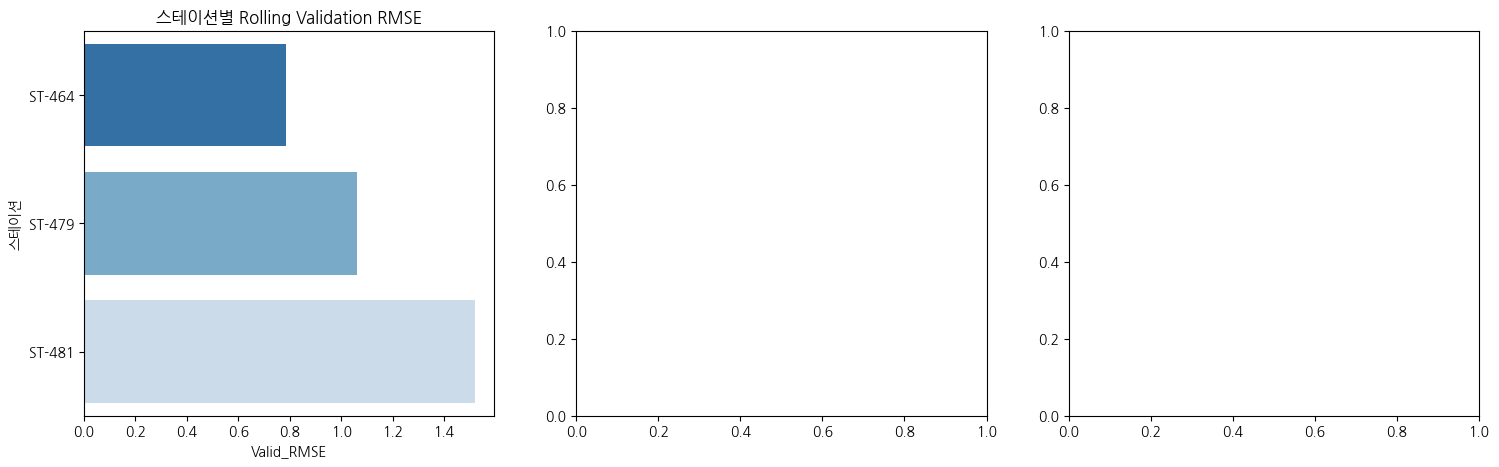

In [28]:
# 스테이션별 개별 모델 성능 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=station_model_result_df, x='Valid_RMSE', y='스테이션', ax=axes[0], palette='Blues_r')
axes[0].set_title('스테이션별 Rolling Validation RMSE')

sns.barplot(data=station_model_result_df, x='Test_RMSE', y='스테이션', ax=axes[1], palette='Greens_r')
axes[1].set_title('스테이션별 2025 Test RMSE')

sns.barplot(data=station_model_result_df, x='Test_R2', y='스테이션', ax=axes[2], palette='Oranges_r')
axes[2].set_title('스테이션별 2025 Test R2')

plt.tight_layout()
plt.show()


## 15. 합산 모델 vs 개별 모델 비교

이 섹션에서는 3개 스테이션 각각에 대해 아래 두 방식을 비교합니다.

- 합산 모델: 3개 스테이션을 함께 학습한 추천 최종 모델
- 개별 모델: 각 스테이션만 따로 학습한 최적 모델

운영 관점에서는 어떤 방식이 스테이션별 수요 예측에 더 적합한지 확인할 수 있습니다.


In [ ]:
# 합산 모델 vs 개별 모델 비교 테이블
combined_vs_individual_results = []

for station_id in individual_stations:
    station_test = final_test[final_test['시작_대여소_ID'] == station_id].copy()
    X_station_test_combined = station_test[final_features].fillna(0)
    y_station_test = station_test[target]

    combined_pred = np.clip(np.expm1(final_best_model.predict(X_station_test_combined)), 0, None)

    individual_station_test = single_station_df[
        (single_station_df['시작_대여소_ID'] == station_id) & (single_station_df['year'] == 2025)
    ].copy()
    X_station_test_individual = individual_station_test[individual_features].fillna(0)
    individual_pred = np.clip(np.expm1(station_best_models[station_id].predict(X_station_test_individual)), 0, None)

    combined_vs_individual_results.append({
        '스테이션': station_id,
        '모델 구분': '합산 모델',
        'MAE': mean_absolute_error(y_station_test, combined_pred),
        'RMSE': np.sqrt(mean_squared_error(y_station_test, combined_pred)),
        'R2': r2_score(y_station_test, combined_pred)
    })
    combined_vs_individual_results.append({
        '스테이션': station_id,
        '모델 구분': '개별 모델',
        'MAE': mean_absolute_error(y_station_test, individual_pred),
        'RMSE': np.sqrt(mean_squared_error(y_station_test, individual_pred)),
        'R2': r2_score(y_station_test, individual_pred)
    })

combined_vs_individual_df = pd.DataFrame(combined_vs_individual_results).sort_values(['스테이션', 'RMSE'])
display(combined_vs_individual_df)


,스테이션,모델 구분,MAE,RMSE,R2
0,ST-464,합산 모델,0.330457,0.720470,0.051745
1,ST-464,개별 모델,0.332071,0.721070,0.050166
5,ST-479,개별 모델,0.537190,0.943442,0.124957
4,ST-479,합산 모델,0.528462,0.945043,0.121985
2,ST-481,합산 모델,0.739976,1.200058,0.187163
3,ST-481,개별 모델,0.735407,1.200882,0.186047


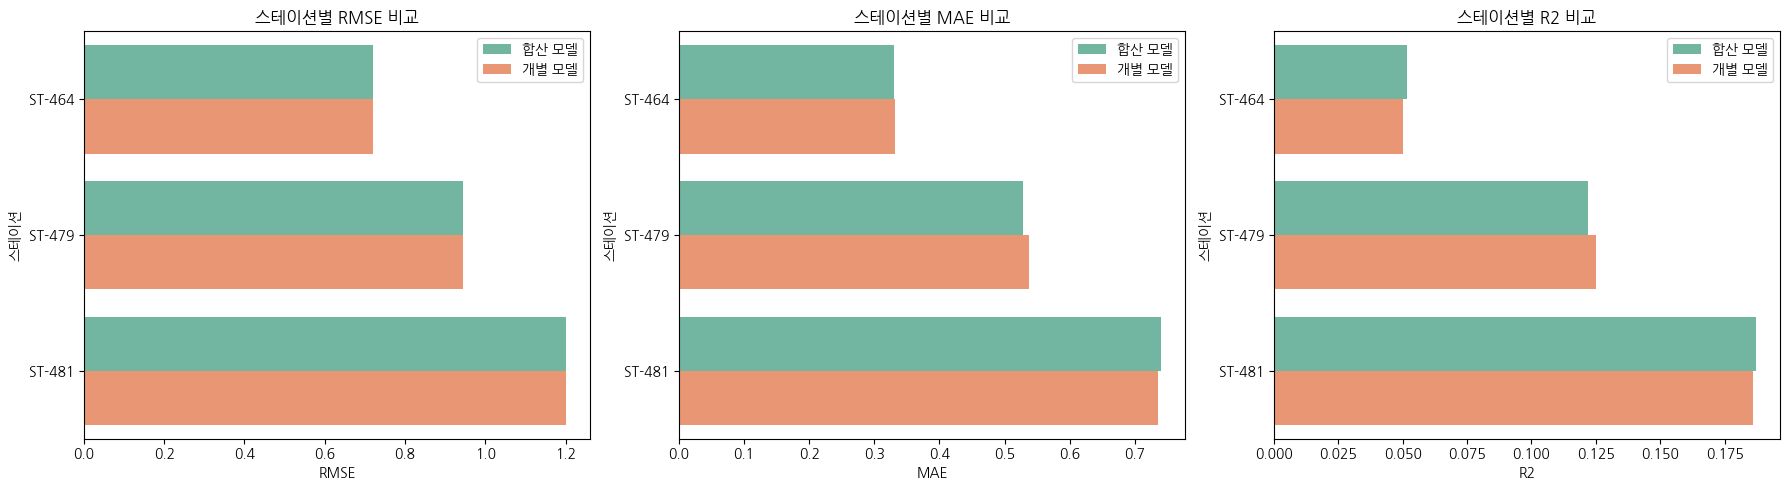

In [ ]:
# 합산 모델 vs 개별 모델 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=combined_vs_individual_df, x='RMSE', y='스테이션', hue='모델 구분', ax=axes[0], palette='Set2')
axes[0].set_title('스테이션별 RMSE 비교')

sns.barplot(data=combined_vs_individual_df, x='MAE', y='스테이션', hue='모델 구분', ax=axes[1], palette='Set2')
axes[1].set_title('스테이션별 MAE 비교')

sns.barplot(data=combined_vs_individual_df, x='R2', y='스테이션', hue='모델 구분', ax=axes[2], palette='Set2')
axes[2].set_title('스테이션별 R2 비교')

for ax in axes:
    ax.legend(loc='best')

plt.tight_layout()
plt.show()
